#LAB 4:  
#BÀI THỰC HÀNH CHUẨN BỊ DỮ LIỆU

# PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng
đầu tiên.

In [45]:
import pandas as pd

def load_data():
    return pd.read_csv('/content/drive/MyDrive/DuLieu/titanic_disaster.csv')

df = load_data()
df.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat
map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked

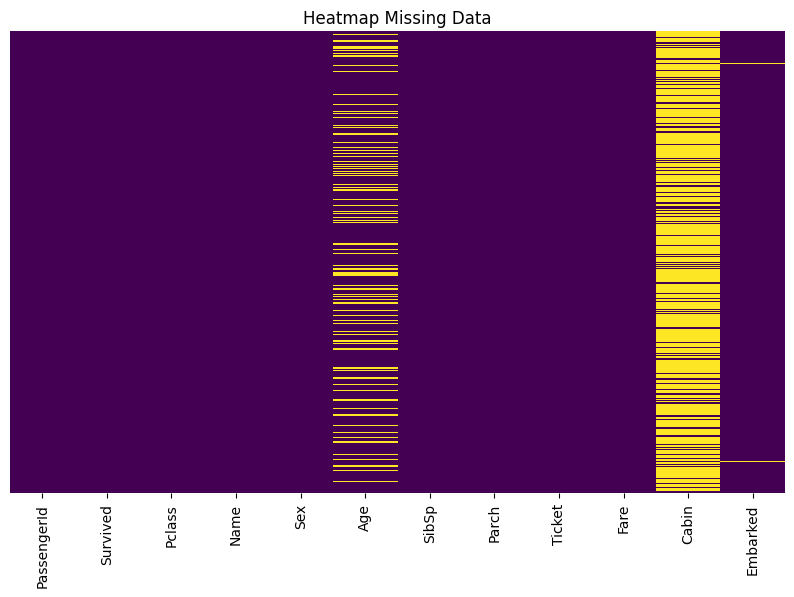

In [46]:
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage (%)': missing_percent
}).sort_values('Missing Values', ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap Missing Data')
plt.show()

3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi
tách cột xong thì xóa luôn cột Name

In [47]:
df[['firstName', 'secondName']] = df['Name'].str.split(',', n=1, expand=True)

df.drop('Name', axis=1, inplace=True)

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry


4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F

In [48]:
df['Sex'] = df['Sex'].replace({'male': 'M', 'female': 'F'})

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,firstName,secondName
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry


5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa
ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng
vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau

a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân
phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm
hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.

b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực
quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map.

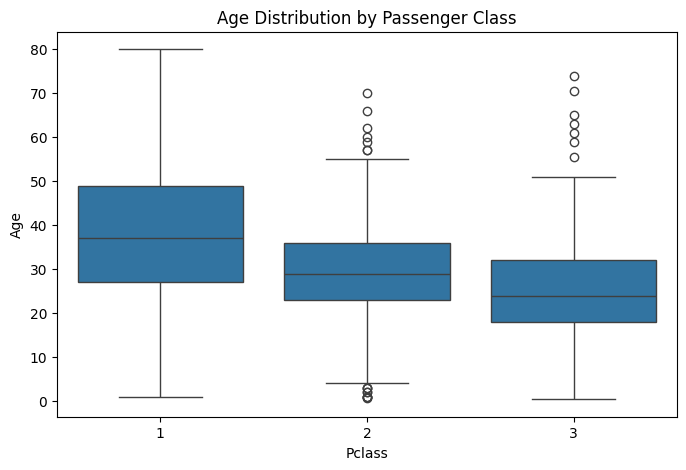

,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Age Distribution by Passenger Class')
plt.show()

df.groupby('Pclass')['Age'].mean()

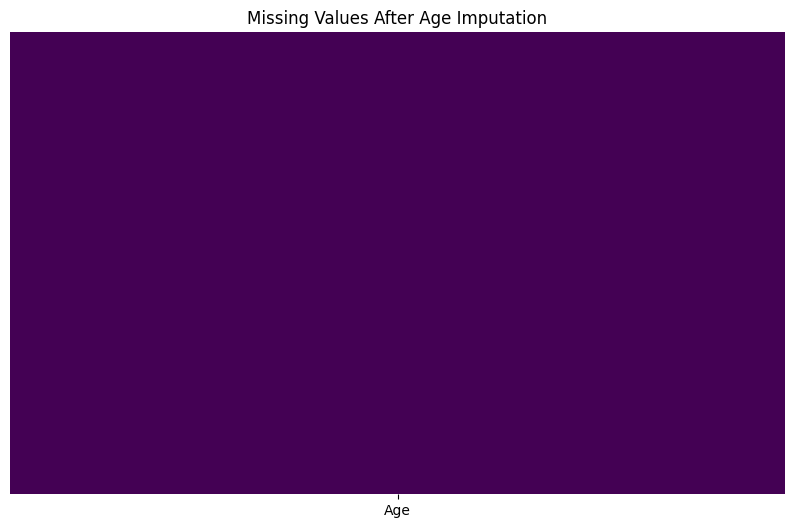

In [50]:
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.mean())
)

df[['PassengerId', 'Pclass', 'Age']].head(10)

plt.figure(figsize=(10,6))
sns.heatmap(df[['Age']].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values After Age Imputation')
plt.show()

6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa
trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult
và ( age > 60): Older

In [60]:
df['Agegroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 60, float('inf')],
    labels=['Kid', 'Teen', 'Adult', 'Older']
)

df[['Age', 'Agegroup']].head(10)

,Age,Agegroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult
5,NaN,NaN
6,54.0,Adult
7,2.0,Kid
8,27.0,Adult
9,14.0,Teen


7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách  Mr,
Mrs, Miss, Master ra khỏi “secondName”

In [52]:
df['namePrefix'] = df['secondName'].str.extract(r'(Mr|Mrs|Miss|Master)')

df[['secondName', 'namePrefix']].head(10)

,secondName,namePrefix
0,Mr. Owen Harris,Mr
1,Mrs. John Bradley (Florence Briggs Thayer),Mr
2,Miss. Laina,Miss
3,Mrs. Jacques Heath (Lily May Peel),Mr
4,Mr. William Henry,Mr
5,Mr. James,Mr
6,Mr. Timothy J,Mr
7,Master. Gosta Leonard,Master
8,Mrs. Oscar W (Elisabeth Vilhelmina Berg),Mr
9,Mrs. Nicholas (Adele Achem),Mr


8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối
với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch

In [59]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']

df[['SibSp', 'Parch', 'familySize']].head(10)

,SibSp,Parch,familySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách
dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0.

In [54]:
df['Alone'] = (df['familySize'] == 1).astype(int)

df[['familySize', 'Alone']].head(100)

,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
...,...,...
95,1,1
96,1,1
97,2,0
98,2,0


10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính
cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu
thì thay thế bằng “Unknown”

In [55]:
df['typeCabin'] = df['Cabin'].fillna('Unknown').str[0]

df[['Cabin', 'typeCabin']].head(100)

,Cabin,typeCabin
0,NaN,U
1,C85,C
2,NaN,U
3,C123,C
4,NaN,U
...,...,...
95,NaN,U
96,A5,A
97,D10 D12,D
98,NaN,U


11. Loại bỏ dữ liệu thừa đối với các hành khách xuất hiện trong cả 2 tập dữ liệu huấn luyện  
(train.csv) và đánh giá (test.csv). Ưu tiên giữ lại dữ liệu trong tập huấn luyện.

# PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA

12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính.





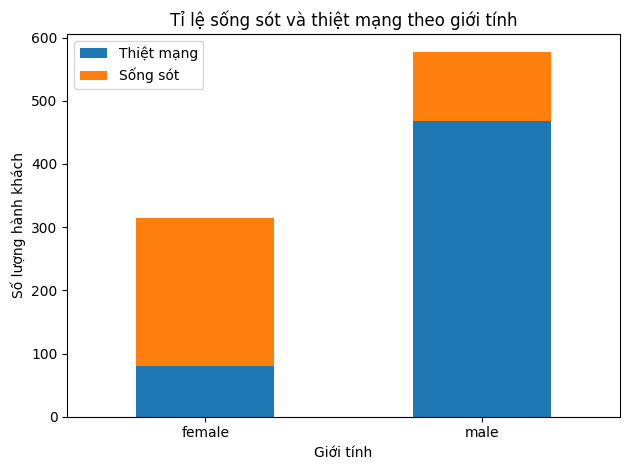

In [56]:
df = load_data()
group = df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)
ax = group.plot(kind='bar', stacked=True)
plt.title('Tỉ lệ sống sót và thiệt mạng theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng hành khách')
plt.legend(['Thiệt mạng', 'Sống sót'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách

(Pclass).


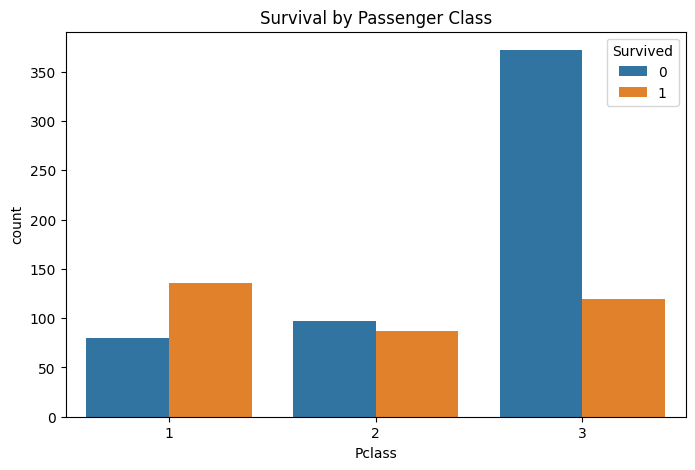

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

Hành khách hạng 1 có số lượng sống sót cao hơn tương đối so với số thiệt mạng.

Hành khách hạng 3 có số lượng thiệt mạng lớn nhất.

Pclass là một đặc trưng quan trọng ảnh hưởng đến khả năng sống sót.

Hành khách thuộc hạng vé cao thường có cơ hội sống sót tốt hơn.

14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác



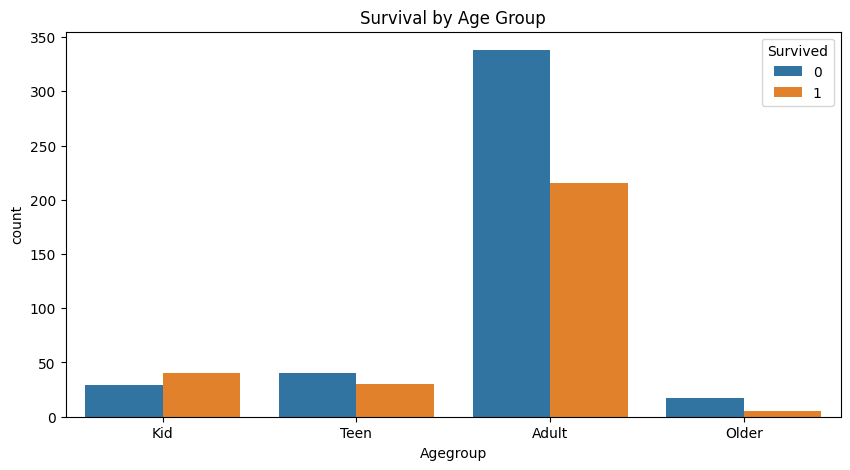

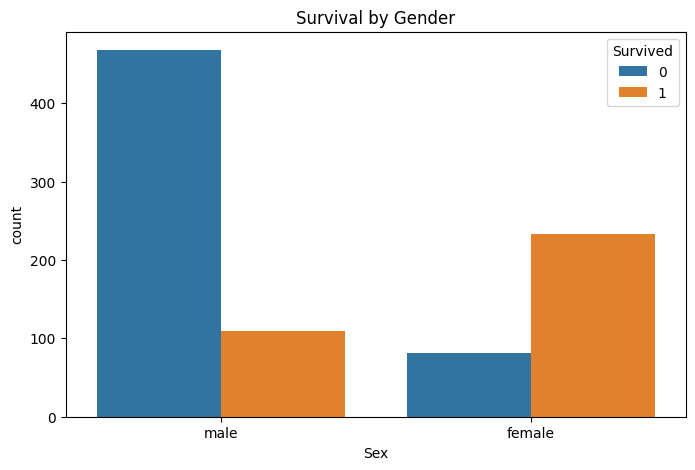

In [61]:
plt.figure(figsize=(10,5))
sns.countplot(x='Agegroup', hue='Survived', data=df)
plt.title('Survival by Age Group')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

Nữ giới có tỷ lệ sống sót cao hơn nam giới.

Nhóm trẻ em (Kid) có tỷ lệ sống sót tương đối cao.

Nhóm người lớn (Adult) chiếm số lượng hành khách lớn nhất nên cũng có số lượng thiệt mạng lớn.

Giới tính và độ tuổi đều có ảnh hưởng đến khả năng sống sót.

15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng


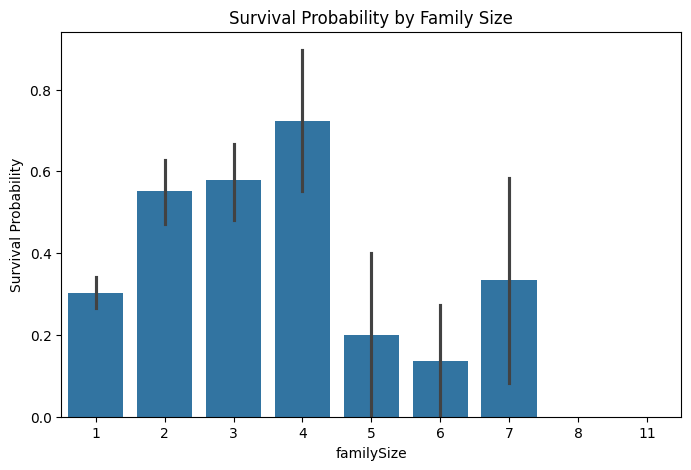

In [62]:
plt.figure(figsize=(8,5))
sns.barplot(x='familySize', y='Survived', data=df)
plt.title('Survival Probability by Family Size')
plt.ylabel('Survival Probability')
plt.show()

Hành khách đi một mình hoặc đi cùng nhóm nhỏ thường có tỷ lệ sống sót cao hơn.

Các nhóm gia đình quá đông có xu hướng giảm khả năng sống sót.

Quy mô nhóm đi cùng có thể ảnh hưởng đến việc di chuyển và tiếp cận xuồng cứu sinh.

familySize là một đặc trưng hữu ích cho việc dự đoán khả năng sống sót.

16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé


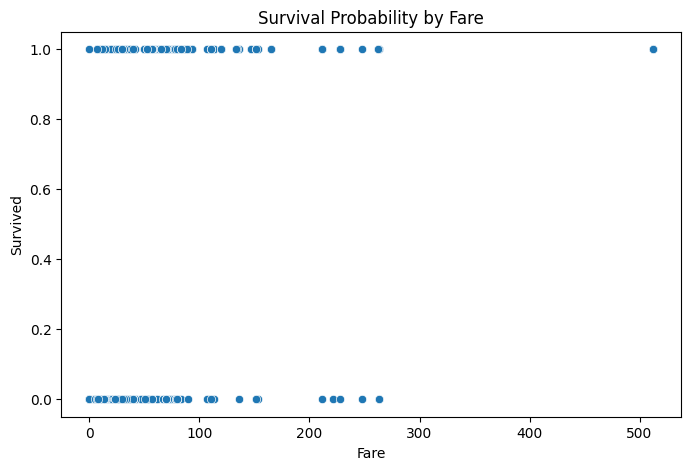

In [63]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Fare', y='Survived', data=df)
plt.title('Survival Probability by Fare')
plt.show()

Hành khách có giá vé cao thường xuất hiện nhiều hơn trong nhóm sống sót.

Giá vé có mối liên hệ với hạng hành khách (Pclass).

Những người trả giá vé cao thường thuộc hạng 1 hoặc hạng 2 và có điều kiện tiếp cận cứu hộ tốt hơn.

Fare là một biến có giá trị trong việc dự đoán khả năng sống sót.

17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và cảng sẽ cập bến.

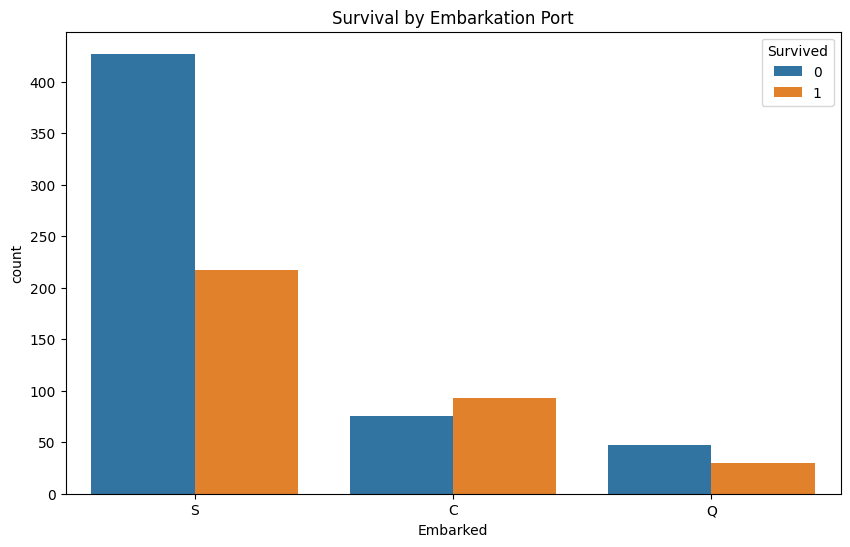

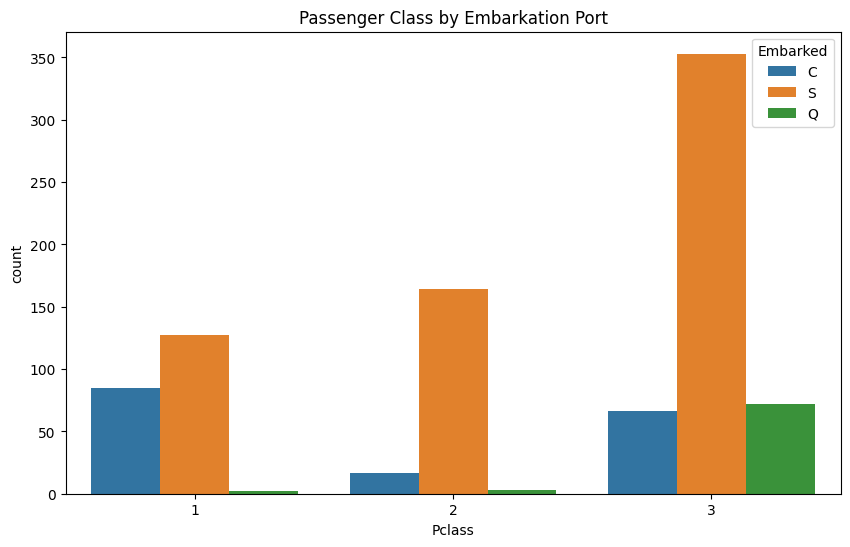

In [64]:
plt.figure(figsize=(10,6))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Embarkation Port')
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(x='Pclass', hue='Embarked', data=df)
plt.title('Passenger Class by Embarkation Port')
plt.show()

Số lượng hành khách và tỷ lệ sống sót khác nhau giữa các cảng lên tàu.

Một số cảng có nhiều hành khách hạng 3 hơn nên tỷ lệ thiệt mạng có thể cao hơn.

Hạng hành khách và cảng lên tàu có mối liên hệ nhất định.

Việc kết hợp đặc trưng Pclass và Embarked giúp phân tích rõ hơn khả năng sống sót của hành khách.